## Business forecasting final project


In [2]:
import operator

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from mlforecast import MLForecast
from mlforecast.lag_transforms import Combine, RollingMean
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor

from utilsforecast.evaluation import evaluate
import utilsforecast.losses as ufl

## Part 1. Data preparation
### 1. Reading data, rename column, check missing data, transform to date time
#Loading data
future_values = pd.read_csv('future_values.csv', parse_dates=['date']).rename(
    columns={'date': 'ds', 'store_id': 'unique_id'})
metadata = pd.read_csv('metadata.csv').rename(columns={'store_id': 'unique_id'})
sales_data = pd.read_csv('sales_data.csv', parse_dates=['date']).rename(
    columns={'date': 'ds', 'store_id': 'unique_id', 'sales': 'y'})
sales_data.dtypes

/var/folders/gm/_yp4_bjn6l7dvvpx97_5_c0c0000gn/T/ipykernel_67735/2099085350.py:22: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  sales_data = pd.read_csv('sales_data.csv', parse_dates=['date']).rename(


unique_id                 object
ds                datetime64[ns]
y                          int64
customers                  int64
open                       int64
promo                      int64
state_holiday             object
school_holiday             int64
dtype: object

In [3]:
#Checking implicitly missing values

# Grouping data by each time series
grouped = sales_data.groupby('unique_id')

print("\nDate range per unique_id:")
date_range = sales_data.groupby('unique_id')['ds'].agg(['min', 'max', 'count'])
print(date_range)


Date range per unique_id:
                 min        max  count
unique_id                             
store_1   2013-01-07 2015-07-19    924
store_10  2013-01-07 2015-07-19    924
store_100 2013-01-07 2015-07-19    924
store_101 2013-01-07 2015-07-19    924
store_102 2013-01-07 2015-07-19    924
...              ...        ...    ...
store_95  2013-01-07 2015-07-19    924
store_96  2013-01-07 2015-07-19    924
store_97  2013-01-07 2015-07-19    924
store_98  2013-01-07 2015-07-19    924
store_99  2013-01-07 2015-07-19    924

[676 rows x 3 columns]


In [4]:
# Creating a summary dataframe for visualizing data completeness
summary = grouped.agg(
    count_observed=('ds', 'count'),
    start_date=('ds', 'min'),
    end_date=('ds', 'max')
).reset_index()

summary['expected_count'] = (
        (summary['end_date'].dt.to_period('M') - summary['start_date'].dt.to_period('M')).apply(lambda x: x.n) + 1
)

# Identifying which time series are irregular
summary['is_irregular'] = summary['count_observed'] < summary['expected_count']

filtered = summary[summary['is_irregular'] == True]
display(filtered)
##### As the result shows an empty df, there is no implicitly missing date
# Grouping data by each time series
grouped = future_values.groupby('unique_id')
summary = grouped.agg(
    count_observed=('ds', 'count'),
    start_date=('ds', 'min'),
    end_date=('ds', 'max')
).reset_index()
print(summary)

,unique_id,count_observed,start_date,end_date,expected_count,is_irregular


     unique_id  count_observed start_date   end_date
0      store_1              60 2015-07-20 2015-09-17
1     store_10              60 2015-07-20 2015-09-17
2    store_100              60 2015-07-20 2015-09-17
3    store_101              60 2015-07-20 2015-09-17
4    store_102              60 2015-07-20 2015-09-17
..         ...             ...        ...        ...
671   store_95              60 2015-07-20 2015-09-17
672   store_96              60 2015-07-20 2015-09-17
673   store_97              60 2015-07-20 2015-09-17
674   store_98              60 2015-07-20 2015-09-17
675   store_99              60 2015-07-20 2015-09-17

[676 rows x 4 columns]


In [5]:
#Checking NA
future_values.isna().sum()
metadata.isna().sum()
sales_data.isna().sum()

unique_id         0
ds                0
y                 0
customers         0
open              0
promo             0
state_holiday     0
school_holiday    0
dtype: int64

##### There is no explicitly missing value

### 2. Merge the 'metadata' with 'sales_data' and 'future_values'

In [6]:
sales_merged = pd.merge(sales_data, metadata, on='unique_id', how='left')
sales_merged['competition_distance'] = sales_merged['competition_distance'].fillna(sales_merged['competition_distance'].median())
future_merged = pd.merge(future_values, metadata, on='unique_id', how='left')
sales_merged.head()

,unique_id,ds,y,customers,open,promo,state_holiday,school_holiday,store_type,assortment,competition_distance
0,store_1,2015-07-19,0,0,0,0,0,0,c,a,1270.0
1,store_2,2015-07-19,0,0,0,0,0,0,a,a,14130.0
2,store_3,2015-07-19,0,0,0,0,0,0,a,c,24000.0
3,store_4,2015-07-19,0,0,0,0,0,0,a,a,7520.0
4,store_5,2015-07-19,0,0,0,0,0,0,a,c,2030.0


##### No 'customer' data in the 'future_values', if we need to use it for the forecasting, we need to predict the future value of 'customer' first. And if we use a predicted value to forecast the future sales, it must affect the accuracy. So it's better to delete it.

### 3. Transform to weekly data, because the company is interested in weekly forecast to make the plan for weekly inventory and staffing

In [7]:
# Create a weekly bucket：start from Monday
sales_merged['week'] = sales_merged['ds'].dt.to_period('W-MON').dt.start_time

# Make sure state_holiday is string type
sales_merged['state_holiday'] = sales_merged['state_holiday'].astype(str)

# Count how many times each state_holiday type appears per week per store
holiday_counts = (
    sales_merged
    .groupby(['unique_id', 'week', 'state_holiday'])
    .size()
    .unstack(fill_value=0)  # turns into columns
    .reset_index()
    .rename_axis(None, axis=1)  # remove column name
)

# Optional: Rename columns for clarity
holiday_counts.columns = ['unique_id', 'week'] + [f'state_holiday_{col}' for col in holiday_counts.columns[2:]]

# Now aggregate your normal weekly data
weekly_cal = sales_merged.groupby(['unique_id', 'week'], as_index=False).agg({
    'y': 'sum',
    'customers': 'sum',
    'promo': 'mean',  # Ratio can better reflect the intensity of the promotion
    'open': 'mean',   #Percentage of days open per week
    'school_holiday': 'mean',  #Proportion of school holidays in the week
    'store_type': 'first',
    'assortment': 'first',
    'competition_distance': 'first'
})

# Merge the holiday counts in
weekly_cal = weekly_cal.merge(holiday_counts, on=['unique_id', 'week'], how='left')

# Fill in 0 where a holiday type didn’t occur that week
weekly_cal.fillna(0, inplace=True)

weekly_cal = weekly_cal.rename(columns={'week': 'ds'})

weekly_data = weekly_cal.copy()

# Only keep store_1 to store_99
weekly_data = weekly_data[weekly_data['unique_id'].isin([f'store_{i}' for i in range(1, 100)])]

# drop 'customer' and 'state_holiday_0'
weekly_data = weekly_data.drop(columns=['customers', 'state_holiday_0'])

weekly_data

,unique_id,ds,y,promo,open,school_holiday,store_type,assortment,competition_distance,state_holiday_a,state_holiday_b,state_holiday_c
0,store_1,2013-01-01,7176,1.000000,1.000000,1.000000,c,a,1270.0,0,0,0
1,store_1,2013-01-08,30493,0.571429,0.857143,0.571429,c,a,1270.0,0,0,0
2,store_1,2013-01-15,26655,0.142857,0.857143,0.000000,c,a,1270.0,0,0,0
3,store_1,2013-01-22,31732,0.571429,0.857143,0.000000,c,a,1270.0,0,0,0
4,store_1,2013-01-29,31670,0.142857,0.857143,0.000000,c,a,1270.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
89903,store_99,2015-06-16,51761,0.571429,0.857143,0.000000,a,a,2640.0,0,0,0
89904,store_99,2015-06-23,48696,0.142857,0.857143,0.142857,a,a,2640.0,0,0,0
89905,store_99,2015-06-30,55631,0.571429,0.857143,0.714286,a,a,2640.0,0,0,0
89906,store_99,2015-07-07,44007,0.142857,0.857143,0.714286,a,a,2640.0,0,0,0


In [8]:
# same process for future_values
future_merged['week'] = future_merged['ds'].dt.to_period('W-MON').dt.start_time

# No state_holiday information, it's not necessary to count state_holiday

# Aggregate the normal weekly data
weekly_calcu = future_merged.groupby(['unique_id', 'week'], as_index=False).agg({
    'promo': 'mean',  # Ratio can better reflect the intensity of the promotion
    'open': 'mean',   #Percentage of days open per week
    'school_holiday': 'mean',  #Proportion of school holidays in the week
    'state_holiday': 'sum',
    'store_type': 'first',
    'assortment': 'first',
    'competition_distance': 'first'
})

# Fill in 0 where a holiday type didn’t occur that week
weekly_calcu.fillna(0, inplace=True)
weekly_calcu['state_holiday'] = 0

weekly_calcu = weekly_calcu.rename(columns={'week': 'ds'})

weekly_future = weekly_calcu.copy()

# Only keep store_1 to store_99
weekly_future = weekly_future[weekly_future['unique_id'].isin([f'store_{i}' for i in range(1, 100)])]

weekly_future

,unique_id,ds,promo,open,school_holiday,state_holiday,store_type,assortment,competition_distance
0,store_1,2015-07-14,0.000000,1.000000,0.000000,0,c,a,1270.0
1,store_1,2015-07-21,0.142857,0.857143,0.142857,0,c,a,1270.0
2,store_1,2015-07-28,0.714286,0.857143,1.000000,0,c,a,1270.0
3,store_1,2015-08-04,0.571429,0.857143,1.000000,0,c,a,1270.0
4,store_1,2015-08-11,0.142857,0.857143,1.000000,0,c,a,1270.0
...,...,...,...,...,...,...,...,...,...
6755,store_99,2015-08-18,0.571429,0.857143,0.000000,0,a,a,2640.0
6756,store_99,2015-08-25,0.142857,0.857143,0.000000,0,a,a,2640.0
6757,store_99,2015-09-01,0.571429,0.857143,0.000000,0,a,a,2640.0
6758,store_99,2015-09-08,0.142857,0.857143,0.000000,0,a,a,2640.0


By tranforming to ratio, it's better for the tree model (Random Forest/LSTM) to use directly continuous features

In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# 只保留用于检测共线性的变量
X_vif = weekly_data[['open', 'school_holiday', 'state_holiday_a', 'state_holiday_b', 'state_holiday_c']].copy()

# 添加常数项（Intercept）
X_vif = add_constant(X_vif)

# 计算 VIF
vif_result = pd.DataFrame()
vif_result["feature"] = X_vif.columns
vif_result["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif_result)

           feature         VIF
0            const  774.587974
1             open    6.026903
2   school_holiday    1.169856
3  state_holiday_a    3.363278
4  state_holiday_b    2.952827
5  state_holiday_c    2.335618


All VIFs < 2, indicating that there is almost no multicollinearity between these variables, and all can be retained for subsequent modeling.

## Part 2. Exploratory Data Analysis

### Analyze trends, seasonality, holidays, promotion, and store type impact

In [10]:
# seasonality calculation
def compute_seasonality_strength(df):
    results = []

    for uid, group in df.groupby('unique_id'):
        # 确保按时间顺序排列
        group = group.sort_values('ds')

        # 提取目标值
        y = group['y'].values

        # 以“周”作为季节单位，提取 week number (1-52)
        group['week_of_year'] = group['ds'].dt.isocalendar().week

        # 计算每个 week_of_year 的平均值（即“季节成分”）
        seasonal_means = group.groupby('week_of_year')['y'].transform('mean')

        # 残差 = y - 季节均值
        residual = y - seasonal_means.values

        # 强度计算
        var_y = np.var(y)
        var_resid = np.var(residual)
        strength = max(0, 1 - var_resid / var_y) if var_y > 0 else 0

        # 写入结果
        group['seasonality'] = strength
        results.append(group[['unique_id', 'ds', 'seasonality']])

        # 拼接前先删除旧的 seasonality 列（如存在）
        df = df.drop(columns=['seasonality'], errors='ignore')

    # 合并所有 unique_id 的结果
    return pd.merge(df, pd.concat(results), on=['unique_id', 'ds'], how='left')


# 应用函数
weekly_data = compute_seasonality_strength(weekly_data)

# 创建 store_features 表：每个 unique_id 只保留一行（避免重复）
store_features = weekly_data[[
    'unique_id', 'seasonality', 'store_type', 'assortment', 'competition_distance'
]].drop_duplicates(subset='unique_id').reset_index(drop=True)

store_features

,unique_id,seasonality,store_type,assortment,competition_distance
0,store_1,0.761202,c,a,1270.0
1,store_10,0.755376,d,c,4110.0
2,store_11,0.734182,a,c,3270.0
3,store_12,0.697176,a,c,3240.0
4,store_13,0.704363,c,c,550.0
...,...,...,...,...,...
94,store_95,0.810593,a,c,100.0
95,store_96,0.807218,a,a,12540.0
96,store_97,0.417402,d,a,980.0
97,store_98,0.638690,a,a,1070.0


季节性强度是历史数据的统计量，未来预测期无法获取该值，强行加入会导致数据泄露。按强度分组，为不同组选择不同模型（而非作为特征）

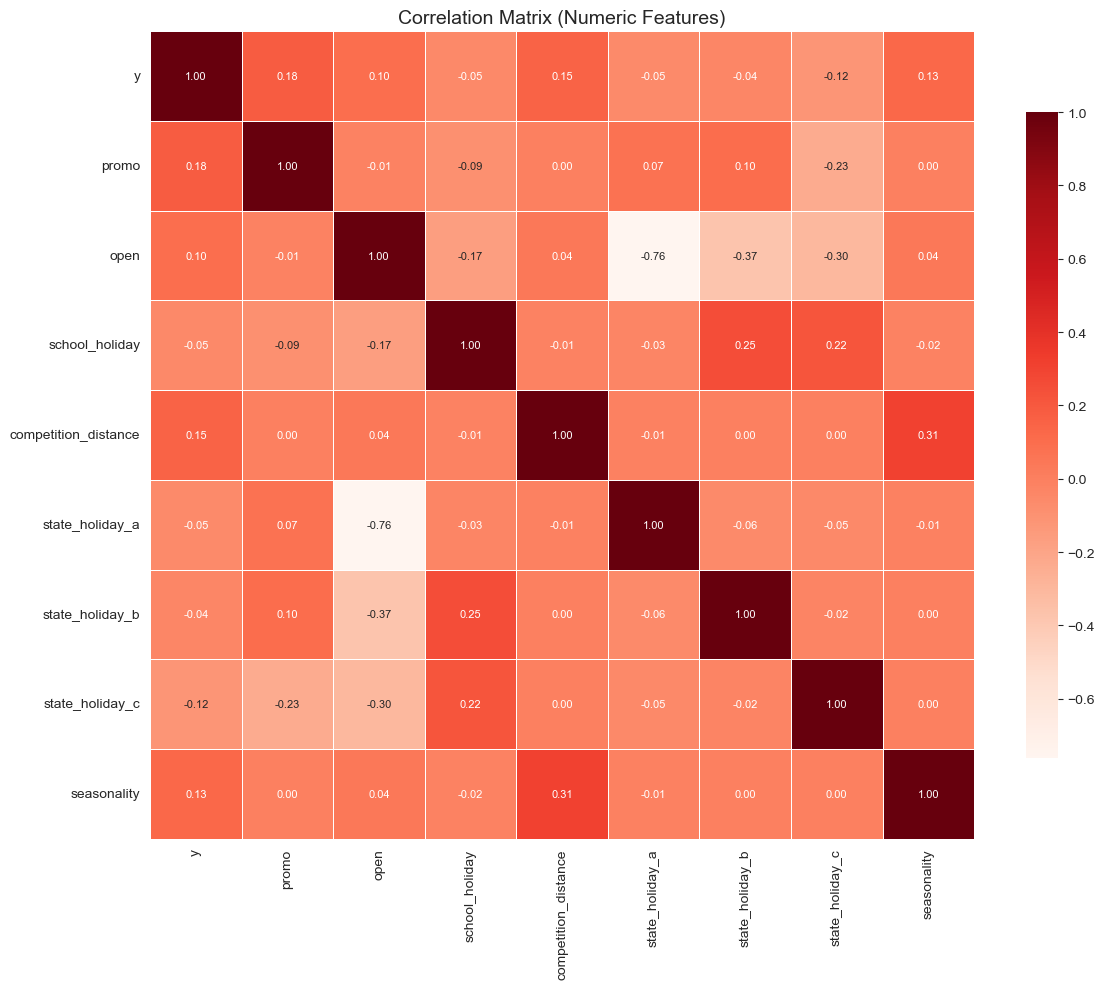

In [11]:
#correlation plot

# the value of 'open','promo','school_holiday' are ratio, between 0-1, however Holidays are discrete events, so counting is more straightforward. For example, "Christmas holiday 2 days" is easier to explain than "Christmas holiday ratio 0.28". 'state_holiday' is a counting value, in order to calculate the correlation and get a better explanation, we should choose 'spearman' method. The calculation method of spearman is based on the covariance of the ranking values.
co_mtx = weekly_data.corr(method='spearman', numeric_only=True)

# Set the size
plt.figure(figsize=(12, 10))

# Use "Reds"
sns.heatmap(
    co_mtx,
    cmap="Reds",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'shrink': 0.8}
)

# set title
plt.title("Correlation Matrix (Numeric Features)", fontsize=14)

# Prevent label overlap
plt.tight_layout()

plt.show()

##### We have used ChatGPT to improve the correlation matrix format and the interaction test part.

In [12]:
# Interaction test: promo-store_type, to see if the effect of promo is different for various type of stores
import statsmodels.formula.api as smf

# Only take necessary data
subset = weekly_data.dropna(subset=['y', 'promo', 'store_type'])

# Interaction term
model = smf.ols(formula='y ~ promo * store_type', data=subset).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     77.33
Date:                Tue, 15 Jul 2025   Prob (F-statistic):           3.47e-80
Time:                        17:10:25   Log-Likelihood:            -1.4186e+05
No. Observations:               13167   AIC:                         2.837e+05
Df Residuals:                   13161   BIC:                         2.838e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept              3.566e+

The result shows, the b - type store sales is the highest, followed by a - type store, third is d - type, and the last one is c - type. Promo significantly boosts sales and has a sales boosting effect on all four types of stores.The interaction term is not significant(all p values are > 0.1), indicating that promotion has similar effects on different types of stores.So when analyzing the relationship between 'promo' and 'sales', there is no need to analyze them separately by store type.

# interaction test for store_type 与 assortment 对销售额的交互作用

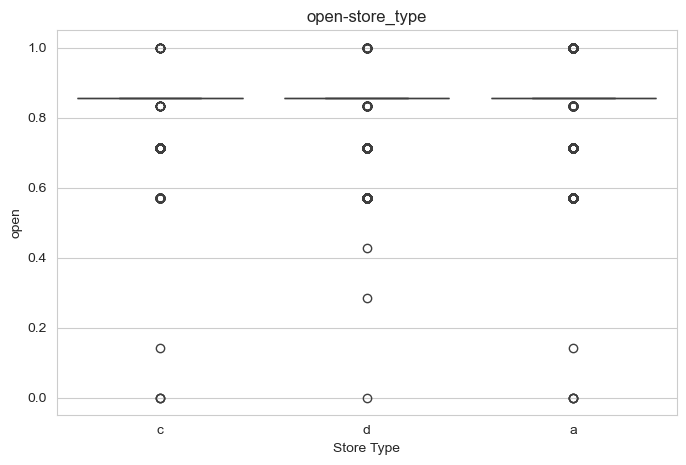

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     19.16
Date:                Tue, 15 Jul 2025   Prob (F-statistic):           4.83e-19
Time:                        17:10:25   Log-Likelihood:            -1.4200e+05
No. Observations:               13167   AIC:                         2.840e+05
Df Residuals:                   13161   BIC:                         2.841e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

In [13]:
# the relationship between store_type and competition_distance
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.boxplot(x='store_type', y='open', data=weekly_data)
plt.title("open-store_type")
plt.ylabel("open")
plt.xlabel("Store Type")
plt.show()

subset_2 = weekly_data.dropna(subset=['y', 'state_holiday_b', 'store_type'])

# Interaction term
model_2 = smf.ols(formula='y ~ state_holiday_b * store_type', data=subset_2).fit()

print(model_2.summary())
# def add_lags(weekly_data, lags):
#     for lag in lags:
#         weekly_data[f"lag_{lag}"] = weekly_data.groupby("unique_id")["y"].shift(lag)
#     return weekly_data
#
# # 添加滞后特征
# weekly_data = add_lags(weekly_data, lags=[1, 2, 4, 13, 52])
#
# # 只删除所有 lag 特征中包含 NaN 的行
# lag_cols = [f"lag_{lag}" for lag in [1, 2, 4, 13, 52]]
# weekly_data.dropna(subset=lag_cols, inplace=True)
# weekly_data
# # Step 1: Extract lag columns
# lag_cols = [col for col in weekly_data.columns if col.startswith("lag_")]
#
# # Step 2: Extract numeric feature columns (excluding id, week, y, and lag columns)
# excluded_cols = ['unique_id', 'week', 'y'] + lag_cols
# feature_cols = [col for col in weekly_data.columns
#                 if col not in excluded_cols and pd.api.types.is_numeric_dtype(weekly_data[col])]
#
# # Step 3: Initialize correlation matrix
# correlation_matrix = pd.DataFrame(index=feature_cols, columns=lag_cols, dtype=float)
#
# # Step 4: Compute correlation if both columns have variance and are not all-NaN
# for feature in feature_cols:
#     for lag in lag_cols:
#         x = weekly_data[feature]
#         y = weekly_data[lag]
#         # 检查是否有有效值和非恒定值
#         if x.nunique(dropna=True) > 1 and y.nunique(dropna=True) > 1:
#             correlation = x.corr(y)
#         else:
#             correlation = np.nan  # 无法计算相关性
#         correlation_matrix.loc[feature, lag] = correlation
#
# # Step 5: Drop rows/cols with all NaN
# correlation_matrix.dropna(how='all', axis=0, inplace=True)
# correlation_matrix.dropna(how='all', axis=1, inplace=True)
#
# # Step 6: Plot heatmap
# plt.figure(figsize=(12, 8))  # 放大图表
# sns.heatmap(correlation_matrix, annot=True, cmap="Reds", center=0,
#             fmt=".2f", annot_kws={"size": 8})
# plt.title("Correlation between Lag Features and Other Predictors")
# plt.xlabel("Lag Features")
# plt.ylabel("Other Features")
# plt.tight_layout()
# plt.show()
#### think about: open, state_holiday 0,a,b,c???????


## Part 3. Best performing model selection


#### 1. Cross validation for Naive, RWD, Seasonal Naive, Holt-Winters, AutoARIMA,Random Forest, LSTM

In [14]:
# Add is_closed_week, if the store is closed for the whole week（== 1）, the y will be 0 in the forecasting
weekly_data['is_closed_week'] = (weekly_data['open'] == 0).astype(int)

In [15]:
# Define threshold
threshold = 0.7

# Split the stores into two groups
low_stores = weekly_data[weekly_data['seasonality'] < threshold]
high_stores = weekly_data[weekly_data['seasonality'] >= threshold]

# low_stores include middle and low seasonality
low_stores

,unique_id,ds,y,promo,open,school_holiday,store_type,assortment,competition_distance,state_holiday_a,state_holiday_b,state_holiday_c,seasonality,is_closed_week
399,store_12,2013-01-01,8978,1.000000,1.000000,0.000000,a,c,3240.0,0,0,0,0.697176,0
400,store_12,2013-01-08,35747,0.571429,0.857143,0.000000,a,c,3240.0,0,0,0,0.697176,0
401,store_12,2013-01-15,27711,0.142857,0.857143,0.000000,a,c,3240.0,0,0,0,0.697176,0
402,store_12,2013-01-22,35286,0.571429,0.857143,0.000000,a,c,3240.0,0,0,0,0.697176,0
403,store_12,2013-01-29,35897,0.142857,0.857143,0.000000,a,c,3240.0,0,0,0,0.697176,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13029,store_98,2015-06-16,25087,0.571429,0.857143,0.000000,a,a,1070.0,0,0,0,0.638690,0
13030,store_98,2015-06-23,24788,0.142857,0.857143,0.142857,a,a,1070.0,0,0,0,0.638690,0
13031,store_98,2015-06-30,24934,0.571429,0.857143,0.714286,a,a,1070.0,0,0,0,0.638690,0
13032,store_98,2015-07-07,23591,0.142857,0.857143,0.714286,a,a,1070.0,0,0,0,0.638690,0


In [16]:
print(low_stores.dtypes)
print(low_stores.head())
print(low_stores['y'].unique())  # 看看是否有异常值

unique_id                       object
ds                      datetime64[ns]
y                                int64
promo                          float64
open                           float64
school_holiday                 float64
store_type                      object
assortment                      object
competition_distance           float64
state_holiday_a                  int64
state_holiday_b                  int64
state_holiday_c                  int64
seasonality                    float64
is_closed_week                   int64
dtype: object
    unique_id         ds      y     promo      open  school_holiday  \
399  store_12 2013-01-01   8978  1.000000  1.000000             0.0   
400  store_12 2013-01-08  35747  0.571429  0.857143             0.0   
401  store_12 2013-01-15  27711  0.142857  0.857143             0.0   
402  store_12 2013-01-22  35286  0.571429  0.857143             0.0   
403  store_12 2013-01-29  35897  0.142857  0.857143             0.0   

    store_typ

High seasonality：Naive, Seasonal Naive, Seasonal Window Mean, AutoARIMA, Holt-winters

Low seasonality：Naive, Historical Average, RWD

In [21]:
import pandas as pd
import numpy as np
from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, RandomWalkWithDrift, SeasonalNaive, SeasonalWindowAverage, \
    AutoARIMA, HoltWinters
import utilsforecast.losses as ufl
from utilsforecast.evaluation import evaluate

# Define models for low and middle seasonality: Naive, Historical Average, RWD
models = [Naive(),HistoricAverage(),RandomWalkWithDrift()]
df_cv = low_stores[['unique_id', 'ds', 'y']].copy()

sf = StatsForecast(models=models, freq='W')

# 执行交叉验证
cv_df = sf.cross_validation(
    df=df_cv,
    step_size=13,  # 每次移动4个时间点（例如4周）
    n_windows=9,  # 5个验证窗口
    h=8  # 预测未来8个时间点（例如8周）
)

# 计算评估指标
metrics = evaluate(
    cv_df.drop(columns={'cutoff'}),
    metrics=[ufl.mse, ufl.mape]
)

# 准备模型选择数据
metric_for_selection = 'mse'  # 使用MSE选择最佳模型
model_metrics = metrics[metrics.metric == metric_for_selection].drop('metric', axis=1)
model_metrics = model_metrics.melt(id_vars='unique_id', var_name='method', value_name='metric')
model_metrics = model_metrics.sort_values(['unique_id', 'metric'])

# 计算集成权重
def compute_ensemble_weights(df):
    """为每个时间序列计算不同集成方法的权重"""
    df = df.copy()
    n_models = len(df)

    # 初始化权重列
    df['Best-Fit'] = 0.0
    df['Equal-All'] = 1.0 / n_models
    df['Equal-Best3'] = 0.0
    df['InverseMSE'] = 0.0
    df['InverseMSE-Best3'] = 0.0

    # 最佳模型权重 (100%分配给最佳模型)
    df.iloc[0, df.columns.get_loc('Best-Fit')] = 1.0

    # 平均权重 (所有模型平均分配)
    # 已在上方初始化

    # 最佳3个模型平均权重
    top_n = min(3, n_models)
    df.iloc[:top_n, df.columns.get_loc('Equal-Best3')] = 1.0 / top_n

    # 基于MSE逆加权
    inverse = 1.0 / df['metric']
    total_inverse = inverse.sum()
    if total_inverse > 0:
        df['InverseMSE'] = inverse / total_inverse

    # 基于MSE逆加权 (仅限最佳3个模型)
    if top_n > 0:
        top_inverse = 1.0 / df['metric'][:top_n]
        total_top_inverse = top_inverse.sum()
        if total_top_inverse > 0:
            df.iloc[:top_n, df.columns.get_loc('InverseMSE-Best3')] = top_inverse / total_top_inverse

    # 转换为长格式
    long_weights = df.melt(
        id_vars=['method', 'unique_id'],
        value_vars=['Best-Fit', 'Equal-All', 'Equal-Best3', 'InverseMSE', 'InverseMSE-Best3'],
        var_name='ensemble_type',
        value_name='weight'
    )
    # 仅保留权重大于0的行
    long_weights = long_weights[long_weights['weight'] > 0].reset_index(drop=True)

    return long_weights

# 为每个时间序列计算权重
weights_df = model_metrics.groupby('unique_id', group_keys=False, sort=False).apply(
    compute_ensemble_weights, include_groups=True)

# 创建集成预测 (交叉验证期)
# 将预测结果转换为长格式
forecasts_long = cv_df.melt(
    id_vars=['unique_id', 'ds', 'cutoff'],
    var_name='method',
    value_name='fc'
)

# 合并权重和预测
ensemble_fc = weights_df.merge(forecasts_long, how='left')

# 计算加权预测
ensemble_fc['weighted_fc'] = ensemble_fc['fc'] * ensemble_fc['weight']

# 聚合集成预测结果
ensemble_fc = ensemble_fc.groupby(['unique_id', 'ensemble_type', 'ds', 'cutoff']).agg(
    {'weighted_fc': 'sum'}
).reset_index()

# 转换为宽格式 (每种集成方法一列)
ensemble_fc = ensemble_fc.pivot(
    index=['unique_id', 'ds', 'cutoff'],
    columns='ensemble_type',
    values='weighted_fc'
).reset_index().rename_axis(None, axis=1)

# 合并原始模型预测和集成预测
full_fc = cv_df.merge(ensemble_fc)

# 评估所有模型 (包括集成模型)
all_metrics = evaluate(
    full_fc.drop(columns={'cutoff'}),
    metrics=[ufl.mse, ufl.mape]
)

# 打印模型性能
print("模型性能评估:")
print(all_metrics)

# 创建未来预测
future_fc = sf.forecast(df=df_cv, h=8)

# 创建集成预测 (未来预测期)
future_forecasts_long = future_fc.melt(
    id_vars=['unique_id', 'ds'],
    var_name='method',
    value_name='fc'
)

# 合并权重和未来预测
future_ensemble_fc = weights_df.merge(future_forecasts_long, how='left')

# 计算加权未来预测
future_ensemble_fc['weighted_fc'] = future_ensemble_fc['fc'] * future_ensemble_fc['weight']

# 聚合集成预测结果
future_ensemble_fc = future_ensemble_fc.groupby(['unique_id', 'ensemble_type', 'ds']).agg(
    {'weighted_fc': 'sum'}
).reset_index()

# 转换为宽格式
future_ensemble_fc = future_ensemble_fc.pivot(
    index=['unique_id', 'ds'],
    columns='ensemble_type',
    values='weighted_fc'
).reset_index().rename_axis(None, axis=1)

# 合并原始模型预测和集成预测
full_future_fc = future_fc.merge(future_ensemble_fc)

# 可视化结果 (示例)
# 选择第一个时间序列进行可视化
# example_id = df_cv['unique_id'].iloc[0]
# print(f"\n可视化结果 - 时间序列: {example_id}")

# 绘制历史数据和预测
StatsForecast.plot(
    df=df_cv[df_cv['unique_id'] == example_id],
    forecasts_df=full_future_fc[full_future_fc['unique_id'] == example_id],
    unique_ids=[example_id],
    models=['Naive', 'HistoricAverage', 'RWD', 'InverseMSE-Best3'],
    max_insample_length=52  # 显示最近52个历史点
)

# 返回结果
result = {
    "cross_validation_metrics": all_metrics,
    "future_forecasts": full_future_fc,
    "ensemble_weights": weights_df
}

# 从 model_metrics 中提取每个 unique_id 的最佳模型和对应 metric
best_models = model_metrics.sort_values(['unique_id', 'metric']).groupby('unique_id').first().reset_index()

# 打印结果
print(best_models.rename(columns={'method': 'best_model', 'metric': 'best_metric'}))


模型性能评估:
   unique_id metric         Naive  HistoricAverage           RWD  \
0   store_12    mse  4.196250e+07     4.217738e+07  4.469410e+07   
1   store_16    mse  2.439932e+08     1.212537e+08  2.958789e+08   
2   store_18    mse  4.195861e+07     7.004454e+07  4.260334e+07   
3   store_19    mse  3.269136e+07     4.028578e+07  4.229591e+07   
4   store_21    mse  5.267304e+07     3.597294e+07  6.149949e+07   
..       ...    ...           ...              ...           ...   
75  store_87   mape  1.490079e-01     1.118611e-01  1.596374e-01   
76  store_91   mape  9.537267e-02     8.569133e-02  1.213866e-01   
77  store_93   mape  1.173816e-01     9.230977e-02  1.342053e-01   
78  store_97   mape  1.033994e-01     1.659205e-01  1.156885e-01   
79  store_98   mape  1.125467e-01     1.253468e-01  1.249629e-01   

        Best-Fit     Equal-All   Equal-Best3    InverseMSE  InverseMSE-Best3  
0   4.196250e+07  3.891513e+07  3.891513e+07  3.890949e+07      3.890949e+07  
1   1.212537e+08 

/var/folders/gm/_yp4_bjn6l7dvvpx97_5_c0c0000gn/T/ipykernel_67735/1451406613.py:84: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weights_df = model_metrics.groupby('unique_id', group_keys=False, sort=False).apply(


store_16,62,63,97 has several weeks closed, y and customer are 0, so RWD、AutoARIMA、ETS can not be used!!! Add feature：is_closed_week = (open_sum == 0).
when forecast, if is_closed_week=1，directly output y=0.## Part 4. Advanced Modeling

In [22]:
from statsforecast.models import Naive, SeasonalNaive, AutoARIMA, HoltWinters

# Define models for high seasonality: Naive, Seasonal Naive, AutoARIMA, Holt-winters
high_df = high_stores[['unique_id', 'ds', 'y']]

# 2. 定义模型列表
models_high = [
    Naive(),
    SeasonalNaive(season_length=52),  # 周度季节性
    AutoARIMA(season_length=52),
    HoltWinters(season_length=52)
]

# 3. 创建 StatsForecast 实例
sf_high = StatsForecast(models=models_high, freq='W', n_jobs=-1)

# 4. 执行交叉验证（h=8，step_size=4，n_windows=5）
cv_high = sf_high.cross_validation(
    df=high_df,
    h=8,
    step_size=4,
    n_windows=30
)

# 5. 评估模型性能
metrics_high = evaluate(
    cv_high.drop(columns='cutoff'),
    metrics=[ufl.mse, ufl.mape]
)

# 6. 为每个 unique_id 提取 mse 排序后的模型表现
model_metrics_high = metrics_high[metrics_high.metric == 'mse'].drop(columns='metric')
model_metrics_high = model_metrics_high.melt(id_vars='unique_id', var_name='method', value_name='metric')
model_metrics_high = model_metrics_high.sort_values(['unique_id', 'metric'])

# 7. 计算集成权重（复用原有函数）
weights_high = model_metrics_high.groupby('unique_id', group_keys=False).apply(compute_ensemble_weights)

# 8. 准备集成预测数据（交叉验证）
cv_long_high = cv_high.melt(id_vars=['unique_id', 'ds', 'cutoff'], var_name='method', value_name='fc')
ensemble_cv_high = weights_high.merge(cv_long_high, how='left')
ensemble_cv_high['weighted_fc'] = ensemble_cv_high['fc'] * ensemble_cv_high['weight']

ensemble_cv_high = ensemble_cv_high.groupby(['unique_id', 'ensemble_type', 'ds', 'cutoff']).agg(
    {'weighted_fc': 'sum'}
).reset_index()

ensemble_cv_high = ensemble_cv_high.pivot(
    index=['unique_id', 'ds', 'cutoff'],
    columns='ensemble_type',
    values='weighted_fc'
).reset_index().rename_axis(None, axis=1)

# 9. 合并预测和集成结果
full_cv_high = cv_high.merge(ensemble_cv_high)

# 10. 再次评估所有模型+集成模型
all_metrics_high = evaluate(
    full_cv_high.drop(columns='cutoff'),
    metrics=[ufl.mse, ufl.mape]
)

# 11. 创建未来预测
future_high = sf_high.forecast(df=high_df, h=8)

# 12. 创建集成未来预测
future_long_high = future_high.melt(id_vars=['unique_id', 'ds'], var_name='method', value_name='fc')
ensemble_future_high = weights_high.merge(future_long_high, how='left')
ensemble_future_high['weighted_fc'] = ensemble_future_high['fc'] * ensemble_future_high['weight']

ensemble_future_high = ensemble_future_high.groupby(['unique_id', 'ensemble_type', 'ds']).agg(
    {'weighted_fc': 'sum'}
).reset_index()

ensemble_future_high = ensemble_future_high.pivot(
    index=['unique_id', 'ds'],
    columns='ensemble_type',
    values='weighted_fc'
).reset_index().rename_axis(None, axis=1)

# 13. 合并原始预测与集成预测
full_future_high = future_high.merge(ensemble_future_high)

# 14. 打印性能评估结果
print("🔍 高销量店铺模型性能（包含集成）：")
print(all_metrics_high)

# 15. 打印每个时间序列的最佳模型及其metric
best_models_high = model_metrics_high.groupby('unique_id').first().reset_index()
print("\n🏆 每个高销量时间序列的最佳模型及对应MSE：")
print(best_models_high.rename(columns={'method': 'best_model', 'metric': 'best_mse'}))


Exception: no model able to be fitted